# Displacement controlled tests for out of plane weak layer fracture toughness 

**Valentin Adam**<sup>1,2</sup>, **Bastian Bergfeld**<sup>2</sup>, **Jakob Schöttner**<sup>2</sup>, **Melin Dominique Erin Walet**<sup>2</sup>, **Philipp Weißgraeber**<sup>3</sup>, **Alec van Herwijnen**<sup>2</sup> & **Philipp L. Rosendahl**<sup>1</sup>

<sup>1</sup>Center of Snow and Avalanche Mechanics, Technical University of Darmstadt, Germany.<br>
<sup>2</sup>Department, WSL Institute for Snow and Avalanche Research SLF, Davos, Switzerland.<br>
<sup>3</sup>Faculty of Mechanical Engineering and Marine Technology, University of Rostock, Germany.

---
## CONTENTS

1. [Preamble](#1.-preamble)<br>
2. [Data](#2.-data)<br>
2.1. [Data handling](#2.1.-data-handling)<br>
2.2. [Data structure](#2.2.-data-structure)<br>
2.3. [Import field data](#2.3.-import-field-data)<br>
2.4. [Import and preprocess loading data](#2.4.-import-and-preprocess-loading-data)<br>
3. [Analysis](#3.-analysis)<br>
3.1. [Load signal analysis](#3.1.-load-signal-analysis)<br>
3.2. [Fracture path](#3.2-fracture-path)<br>
4. [Digital Image Correlation](#4.-digital-image-correlation)<br>
4.1. [Camera calibration](#4.1-camera-calibration)<br>
4.2. [Geometry selection](#4.2-geometry-selection)<br>

---
## 1. PREAMBLE

In [11]:
%matplotlib widget

# Third-party imports
from IPython.display import display
import pandas as pd

# Project imports
import data_config as dc
import layout as lo

# Better list display in pandas
pd.set_option('display.max_colwidth', 50)  # Allow longer column content
pd.set_option('display.max_columns', None)  # Show all columns  
pd.set_option('display.width', None)        # No width limit

# Predefine data paths
print(f"Server accessible: {dc.check_server_availability()}")
path_motor_unit_data =  dc.get_data_path('01_raw_data','02_motor_unit_data')
path_videos =  dc.get_data_path('01_raw_data','03_videos')
path_metadata =  dc.get_data_path('01_raw_data','04_metadata')

# Plot setup
%config InlineBackend.figure_formats = 'svg'
%matplotlib inline
%matplotlib widget

# Magic to reload modules
%load_ext autoreload
%autoreload 2

Server accessible: True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# custom color palette
 
lo.print_color_palette()

Color Palette:
red          : #dc0100
orange       : #fa8200
gold         : #ffcd00
light_blue   : #000a51
blue         : #2588bf
indigo       : #75d3f2


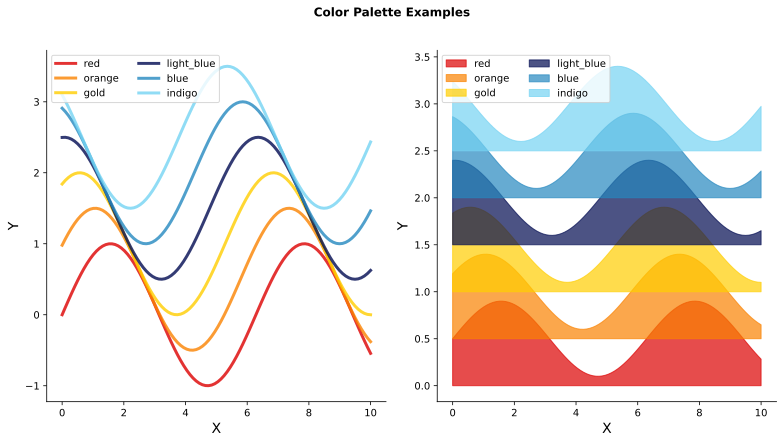

In [4]:
lo.plot_color_examples()

---
## 2. DATA

### 2.1. Data handling

Cross-platform server data access for team collaboration.

In [5]:
# Quick test
print(f"Platform: {dc.get_smb_info()['platform']}")
print(f"Server accessible: {dc.check_server_availability()}")
print(f"Server path: {dc.get_server_path()}")

Using font: Minion Pro
Platform: Darwin
Server accessible: True
Server path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled


In [12]:
#Predefining data paths:

# Raw data paths (01_raw_data folder)

print("Raw Data Paths (01_raw_data folder):")
print("=" * 40)
print("Motor unit data:")
print(f"• Path: {path_motor_unit_data}")
print("-" * 40)
print("Videos:")
print(f"• Path: {path_videos}")
print("-" * 40)
print("Metadata:")
print(f"• Path: {path_metadata}")



Raw Data Paths (01_raw_data folder):
Motor unit data:
• Path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/02_motor_unit_data
----------------------------------------
Videos:
• Path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/03_videos
----------------------------------------
Metadata:
• Path: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata


### 2.2. Data structure 

This section describes the data structure used for the Mode3DC project, which is designed to be both internally organized for team collaboration and externally accessible for data sharing.

#### Data Organization Overview

This project uses a **master dataset approach** with two core Parquet files:

- **`M3DC_raw.parquet`** - Master data containing all experimental measurements
- **`M3DC_raw_info.parquet`** - Information describing each column (units, data types, descriptions)

**Key principles:**
- **Single source of truth**: All data updates go to the master files
- **Type preservation**: Parquet format maintains data types and handles complex structures (lists, tuples)
- **Information tracking**: Every column has corresponding information data for documentation
- **Incremental updates**: New data is merged into existing files rather than creating new ones
- **Analysis separation**: Analysis results are saved to separate files and merged back later

This approach ensures data consistency and traceability throughout the entire workflow.

#### Folder Structure

<div style="font-family: 'Courier New', monospace; background-color: #f8f9fa; padding: 20px; border-radius: 8px; border-left: 4px solid #007bff; margin: 20px 0;">

<strong style="color: #007bff;">2025_Mode_III_displacement_controlled/</strong><br>
├── <span style="color: #8319d7; font-weight: bold;">01_raw_data/</span>                    # Original, unmodified data<br>
│   ├── <span style="color: #6c757d;">01_fieldbooks</span>             
│   ├── <span style="color: #6c757d;">02_motor_unit_data</span><br>
│   ├── <span style="color: #6c757d;">03_videos</span>   # HFR videos 250 fps sony<br> 
│   └── <span style="color: #6c757d;">04_metadata</span> <br> 
│<br>
├── <span style="color: #c54325; font-weight: bold;">02_processed_data/</span>              # Intermediate processing results<br>
├── <span style="color: #51612c; font-weight: bold;">03_analysis_results/</span>            # Analysis outputs (future use)<br>
└── <span style="color: #ac2e85; font-weight: bold;">04_final_outputs/</span>               # Final figures and reports (future use)

</div>

The data is available through following download link: **link**

### 2.3. Import field data

This section imports experimental field data from Excel files into the master Parquet dataset.

**What happens:**
- **Input**: Excel file (`mode_III_dc.xlsx`) containing experimental metadata and measurements
- **Processing**: Data is parsed, type-converted, and validated according to predefined schemas
- **Output**: Two master Parquet files are created/updated:
  - `M3DC_raw.parquet` - Main experimental data
  - `M3DC_raw_info.parquet` - Column metadata (units, data types, descriptions)

**Key features:**
- **Type conversion**: Automatically converts Excel data types (datetime, time, integers, floats, booleans, strings)
- **Time handling**: Converts time formats (HH:MM:SS, mm:ss) to consistent float seconds
- **Force overwrite**: Option to update existing data or create new master files
- **Duplicate detection**: Prevents duplicate columns in both data and metadata
- **Metadata generation**: Creates comprehensive column descriptions for documentation

**Data structure check:**
- Verify that all expected columns are present in the data_export sheet 
- columns which should not be loaded in the master source can be excluded 
- In the data_export sheet the time columns needs to be excel time format 
- make shure to exclude the internal note row from data_export sheet
- Check data types match experimental requirements
- Ensure time data is properly converted to seconds
- Validate that AFN (Automated File Number) identifiers are unique

This step establishes the foundation of the master dataset that all subsequent analysis will build upon.

In [18]:
# Import experimental field data
M3DC_raw, M3DC_raw_info = dc.import_split_and_save_field_data_excel(
    path_metadata+"/mode_III_dc.xlsx", 
    data_type_conversion=True,
    sheet_name="data_export",
    save_as="M3DC_raw",
    force_overwrite=True,
    exclude_columns=['screenshot of the force path']
)

Importing: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/mode_III_dc.xlsx
Reading sheet: data_export
Applying data type conversion...
Converted 34 columns: AFN (integer), date (datetime), T_s1 (float), T_s2 (float), T_s3 (float), rho_1 (float), rho_2 (float), rho_3 (float), rho_4 (float), rho_sub (float), h_s1 (float), h_s2 (float), h_s (float), P_e (float), sf front (string), sf back (string), a (float), psi (float), L (float), weight number (integer), weights (integer), l_dw (float), field row (integer), note (string), quality (string), pixel per mm (float), camera (string), pixel convertation (float), rotation correction (float), shear speed (float), gearbox (integer), motor Unit (integer), motor speed (float), samples per mm (float)
Successfully imported:
  df_raw shape: (14, 35)
  df_raw_info shape: (35, 5)
  Last column in data: samples per mm
  Last abbreviation in metadata: samples per m

In [19]:
M3DC_raw = dc.import_parquet(path_metadata+"/M3DC_raw.parquet")
display(M3DC_raw.head(2))
M3DC_raw_info = dc.import_parquet(path_metadata+"/M3DC_raw_info.parquet")
display(M3DC_raw_info)

Successfully imported Parquet: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet
Shape: (14, 35)
Columns: ['AFN', 'date', 'T_s1', 'T_s2', 'T_s3', 'rho_1', 'rho_2', 'rho_3', 'rho_4', 'rho_sub', 'h_s1', 'h_s2', 'h_s', 'P_e', 'sf front', 'sf back', 'a', 'psi', 'L', 'weight number', 'weights', 'l_dw', 'field row', 'note', 'quality', 'pixel per mm', 'camera', 'field workers', 'pixel convertation', 'rotation correction', 'shear speed', 'gearbox', 'motor Unit', 'motor speed', 'samples per mm']


,AFN,date,T_s1,T_s2,T_s3,rho_1,rho_2,rho_3,rho_4,rho_sub,h_s1,h_s2,h_s,P_e,sf front,sf back,a,psi,L,weight number,weights,l_dw,field row,note,quality,pixel per mm,camera,field workers,pixel convertation,rotation correction,shear speed,gearbox,motor Unit,motor speed,samples per mm
0,176,2025-02-28,-5.5,-3.9,-3.5,137.0,142.0,141.0,158.0,NaN,110.0,110.0,110.0,111.0,315.0,315.0,100.0,25.5,NaN,<NA>,<NA>,NaN,1,None,None,NaN,None,Amelie Fees,NaN,NaN,2000.0,246,2,644.0,1341.0
1,177,2025-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,<NA>,<NA>,NaN,<NA>,None,None,NaN,None,None,NaN,NaN,2000.0,246,2,644.0,1341.0


Successfully imported Parquet: /Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw_info.parquet
Shape: (35, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
0,AFN,None,Integer,automated file number,Automated file number saved from motor untit a...
1,L,mm,Float,Length of the slab,Length of the slab. In those experiments where...
2,P_e,N,Float,critical fracture Force estimate,The force was red directly from display in fie...
3,T_s1,◦C,Float,Slabs temperature at the top,Slabs temperature right after experiment 15 mm...
4,T_s2,◦C,Float,Slabs temperature at the bottom,Slabs temperature right after experiment 15 mm...
5,T_s3,◦C,Float,Substratum temperature,Temperature of the substratum 15 mm below weak...
6,a,mm,Float,pre cut/notch distance,Distance of precut inserted prior experiment t...
7,camera,None,String,Camera in use,The model of the camera which was used for fil...
8,date,None,Datetime: YYYY-MM-DD,date,date of the experiment
9,field row,None,Int,location where experiment was extracted.,The row where the experiment took place/was lo...


### 2.4. Import and preprocess loading data

This section merges load signal data from multiple CSV files into the master Parquet dataset.

**What happens:**
- **Input**: Multiple CSV files containing distance-force measurements (`MSCU{AFN}_samples.csv`)
- **Processing**: Load data is merged as list format into the master dataset
- **Output**: Updated master Parquet files with new columns:
  - `w_data` (distance) - List of distance measurements in mm
  - `P_data` (force) - List of force measurements in N

**Key features:**
- **List format storage**: Each AFN row contains complete time series as lists
- **Automatic detection**: Finds all load data files matching the pattern
- **Force overwrite**: Option to update existing load data or skip if already present
- **Metadata generation**: Creates column descriptions for distance and force measurements
- **Duplicate prevention**: Checks for existing columns before adding new ones

**Data structure check:**
- Verify that distance and force lists have matching lengths
- Check that all AFNs from master data have corresponding load files
- Ensure proper units (mm for distance, N for force)
- Validate that time series data is properly formatted as lists

**Integration**: This step adds the mechanical loading data that will be analyzed in the next section using the interactive load signal analyser.

### ON4PB

In [8]:
# Merge raw data with load data 
ON4PB_raw_load,ON4PB_raw_load_info = dc.merge_load_data(
    raw_data_path=raw_metadata_path_ON4PB+"/ON4PB_raw.parquet",
    raw_info_data_path=raw_metadata_path_ON4PB+"/ON4PB_raw_info.parquet", 
    load_data_dir=raw_force_data_path_ON4PB,
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Adding new load data columns: w_data, P_data
Found loading data for AFN 1001: 19959 measurements
Found loading data for AFN 1003: 16984 measurements
Found loading data for AFN 1004: 27658 measurements
Found loading data for AFN 1005: 34105 measurements
Found loading data for AFN 1006: 15270 measurements
Found loading data for AFN 1007: 13238 measurements
Found loading data for AFN 1008: 13490 measurements
Found loading data for AFN 1009: 11289 measurements
Found loading data for AFN 1011: 6556 measurements
Found loading data for AFN 1013: 22408 measurements
Found loading data for AFN 1015: 7223 measurements
Found loading data for AFN 1018: 13738 measurements
Found loading data for AFN 1020: 7793 measurements
Found loading d

In [9]:
ON4PB_raw = dc.import_parquet(raw_metadata_path_ON4PB+"/ON4PB_raw.parquet")
display(ON4PB_raw.tail(2))
ON4PB_raw_info = dc.import_parquet(raw_metadata_path_ON4PB+"/ON4PB_raw_info.parquet")
display(ON4PB_raw_info)


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Shape: (107, 46)
Columns: ['AFN', 'date', 'v', 'h', 'LOI', 'letterslot', 'notch percentage', 'combination', 'd', 'a', 'rho_1', 'rho_2', 'rho', 'preload', 'start preload', 'end preload', 'P_pre', 'quality of preload', 'exp start', 'exp end', 'peak number', 'P_e', 'quality', 'success', 'note', 'crack growth', 'gearbox', 'motor Unit', 'shear speed', 'motor speed', 'samples per mm', 'offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot', 'T_s', 'sample_geometry_raw', 'camera', 'pixel convertation', 'rotation correction', 'sample_geometry_FEM', 'w_data', 'P_data']


,AFN,date,v,h,LOI,letterslot,notch percentage,combination,d,a,rho_1,rho_2,rho,preload,start preload,end preload,P_pre,quality of preload,exp start,exp end,peak number,P_e,quality,success,note,crack growth,gearbox,motor Unit,shear speed,motor speed,samples per mm,offset_region,P_off,start_lin,end_lin,k,P_c,F_dot,T_s,sample_geometry_raw,camera,pixel convertation,rotation correction,sample_geometry_FEM,w_data,P_data
105,1205,2025-01-24,1650,105,U,A,i,Ai,0.0,70.0,338.0,343.0,340.5,1204,00:08:00,00:14:00,78.155,0,00:10:00,00:14:00,0,124.940,0,True,None,1,111,1,1650,240,1210,"[0.0, 5.5926]",3.871835,"[6.6909, 76.6441]","[6.8256, 119.3182]",316.808463,"[6.8554, 124.9396]",522.733964,-4.7,None,sony,0.354859,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8987, 3.8685, 3.8685, 3.8685, 3.8685, 3.868..."
106,1207,2025-01-24,1650,105,D,A,i,Ai,0.0,70.0,379.0,391.0,385.0,1206,00:08:00,00:15:00,120.285,0,00:08:00,00:12:00,0,129.412,0,True,None,1,111,1,1650,240,1210,"[0.0, 3.6149]",3.867655,"[3.8322, 73.5916]","[4.0107, 122.2498]",272.594958,"[4.0479, 129.4125]",449.781681,-3.6,None,sony,0.354859,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8685, 3.8685, 3.8382, 3.8685, 3.8382, 3.898..."


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Shape: (46, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
0,AFN,None,Integer,automated file number,Automated file number saved from motor untit a...
1,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...
2,LOI,None,"String: U, L",Layer of interest,Upper (U) or Lower (L) layer of interest
3,P_c,N,Coordinates as Tuple,critical fracture Force,critical force at the time of the crack onset
4,P_data,N,List,force,force signal of the load cell
5,P_e,N,Float,critical fracture Force estimate,The force was red manually out of the plot wit...
6,P_off,N,Float,offset of the load cell,offset which was calculated on the signal duri...
7,P_pre,N,Float,critical fracture Force estimate,The force was red manually out of the plot wit...
8,T_s,◦C,Float,Sample Temperature,Post experimental emperature in the middle of ...
9,a,mm,Float,notch length,length of notch


In [10]:
vis.distance_force_plot(raw_metadata_path_ON4PB+"/ON4PB_raw.parquet", title="ON4PB distance vs load")

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet


Output()

### VS3PB

**VS3PB Distance Scaling Correction (AFN 275-352)**

An older encoder configuration at 0.7 mm/s recorded 33270 impulses per mm with 3327 samples per mm, resulting in 200Hz sampling instead of the intended 2kHz. The correct configuration should be 1210 encoder impulses per mm with 1210 samples per mm. To correct this, the `distance [mm]` values for AFN 275-352 were permanently multiplied by 10 in the source CSV files using `dc.fix_vs3pb_distance_scaling()`. This one-time correction ensures all future data loads have the correct distance scaling.

In [ ]:
# Step 1: Preview changes
#results = dc.fix_vs3pb_distance_scaling(raw_force_data_path_VS3PB, dry_run=True)

# Step 2: Apply changes (once confirmed)
#results = dc.fix_vs3pb_distance_scaling(raw_force_data_path_VS3PB, dry_run=False)

Processing AFNs 275 to 352 (inclusive)
Directory: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/motor_unit_data

AFN 275: Scaled distance from [0.000, 0.981] to [0.000, 9.805] ✓
AFN 276: Scaled distance from [0.000, 0.415] to [0.000, 4.151] ✓
AFN 277: Scaled distance from [0.000, 0.432] to [0.000, 4.325] ✓
AFN 278: Scaled distance from [0.000, 0.500] to [0.000, 5.005] ✓
AFN 279: Scaled distance from [0.000, 0.575] to [0.000, 5.750] ✓
AFN 280: Scaled distance from [0.000, 0.498] to [0.000, 4.980] ✓
AFN 281: Scaled distance from [0.000, 2.224] to [0.000, 22.242] ✓
AFN 282: Scaled distance from [0.000, 1.260] to [0.000, 12.597] ✓
AFN 283: Scaled distance from [0.000, 0.916] to [0.000, 9.158] ✓
AFN 284: Scaled distance from [0.000, 1.665] to [0.000, 16.649] ✓
AFN 285: Scaled distance from [0.000, 0.559] to [0.000, 5.594] ✓
AFN 286: Scaled distance from [0.000, 0.811] to [0.000, 8.109] ✓
AFN 287: Scaled distance from [0.000, 0.774] to [0.000, 7.737] ✓
AFN 288:

In [11]:
# Merge raw data with load data 
VS3PB_raw_load,VS3PB_raw_load_info = dc.merge_load_data(
    raw_data_path=raw_metadata_path_VS3PB+"/VS3PB_raw.parquet",
    raw_info_data_path=raw_metadata_path_VS3PB+"/VS3PB_raw_info.parquet", 
    load_data_dir=raw_force_data_path_VS3PB,
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Adding new load data columns: w_data, P_data
Found loading data for AFN 153: 48297 measurements
Found loading data for AFN 154: 20997 measurements
Found loading data for AFN 155: 14930 measurements
Found loading data for AFN 156: 18095 measurements
Found loading data for AFN 157: 16276 measurements
Found loading data for AFN 158: 19932 measurements
Found loading data for AFN 159: 65189 measurements
Found loading data for AFN 160: 25570 measurements
Found loading data for AFN 161: 16177 measurements
Found loading data for AFN 162: 13149 measurements
Found loading data for AFN 163: 36687 measurements
Found loading data for AFN 164: 13456 measurements
Found loading data for AFN 165: 24163 measurements
Found loading data for AF

In [12]:
VS3PB_raw = dc.import_parquet(raw_metadata_path_VS3PB+"/VS3PB_raw.parquet")
display(VS3PB_raw.tail(6))
VS3PB_raw_info = dc.import_parquet(raw_metadata_path_VS3PB+"/VS3PB_raw_info.parquet")
display(VS3PB_raw_info.tail(6))

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Shape: (158, 37)
Columns: ['AFN', 'date', 'v', 'l_s', 'l_v', 'l_f', 'l_P', 'a', 'rho_1', 'rho_2', 'rho', 'P_c', 'peak number', 'exp start', 'exp end', 'quality', 'success', 'crack growth', 'note', 'gearbox', 'motor Unit', 'motor speed', 'samples per mm', 'start_lin', 'end_lin', 'k', 'offset_region', 'P_off', 'F_dot', 'T_s', 'sample_geometry_raw', 'camera', 'pixel convertation', 'rotation correction', 'sample_geometry_FEM', 'w_data', 'P_data']


,AFN,date,v,l_s,l_v,l_f,l_P,a,rho_1,rho_2,rho,P_c,peak number,exp start,exp end,quality,success,crack growth,note,gearbox,motor Unit,motor speed,samples per mm,start_lin,end_lin,k,offset_region,P_off,F_dot,T_s,sample_geometry_raw,camera,pixel convertation,rotation correction,sample_geometry_FEM,w_data,P_data
152,348,2024-03-26,1650.0,380.0,180.0,200.0,0.0,50.0,355.0,358.0,356.5,NaN,1,00:07:00,00:11:00,0,True,1,None,111,1,240.0,3327.0,"[1.614, 80.2708]","[1.638, 97.7242]",727.225000,"[0.0, 0.243]",2.009616,1199.92125,-2.6,None,sony,0.296173,-0.010251,None,"[0.0, 0.0029999999999999, 0.0059999999999999, ...","[2.0098, 2.0098, 2.0249, 2.0249, 2.0098, 2.024..."
153,349,2024-03-26,1650.0,380.0,180.0,200.0,0.0,50.0,350.0,353.0,351.5,NaN,0,00:14:00,00:19:00,0,True,1,None,111,1,240.0,3327.0,"[5.194, 70.1614]","[5.2090000000000005, 85.7108]",1036.626667,"[0.0, 3.928]",1.999744,1710.43400,-2.6,None,sony,0.296173,-0.010251,None,"[0.0, 0.0029999999999999, 0.0059999999999999, ...","[2.0249, 2.04, 1.9947, 2.0098, 2.0098, 1.9947,..."
154,350,2024-03-26,1650.0,380.0,180.0,200.0,0.0,50.0,348.0,356.0,352.0,NaN,1,00:09:00,00:15:00,0,True,1,None,111,1,240.0,3327.0,"[3.5620000000000003, 108.015]","[3.592, 136.8321]",960.570000,"[0.0, 2.131]",2.000715,1584.94050,-2.5,None,sony,0.296173,-0.010251,None,"[0.0, 0.0029999999999999, 0.0059999999999999, ...","[2.0249, 2.0098, 2.0098, 2.0098, 2.0249, 2.009..."
155,351,2024-03-26,1650.0,400.0,200.0,200.0,0.0,50.0,346.0,341.0,343.5,NaN,1,00:11:00,00:16:00,0,True,1,None,111,1,240.0,3327.0,"[2.943, 75.3748]","[2.967, 84.2904]",371.483333,"[0.0, 1.1]",2.032429,612.94750,-2.7,None,sony,0.296173,-0.010251,None,"[0.0, 0.0029999999999999, 0.0059999999999999, ...","[2.0249, 2.0098, 2.0098, 2.0249, 2.0098, 2.024..."
156,352,2024-03-26,1650.0,400.0,200.0,200.0,0.0,50.0,348.0,339.0,343.5,NaN,<NA>,None,None,2,False,<NA>,Disrupted Load signal because we shut down the...,111,1,240.0,3327.0,"[2.943, 75.3748]","[2.967, 84.2904]",371.483333,None,NaN,612.94750,-2.5,None,sony,0.296173,-0.010251,None,None,None
157,<NA>,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,None,None,None,<NA>,<NA>,None,<NA>,<NA>,NaN,NaN,None,None,NaN,None,NaN,NaN,NaN,None,None,NaN,NaN,None,None,None


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Shape: (50, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
44,shear speed,µm/s,Float,shear speed,speed of the driving rod of the motor unit.
45,start preload,mm:ss,String,start time just before contact of load cell,start time for the ffmpeg package to export vi...
46,start_lin,None,Coordinates as Tuple,start of linear signal before failure,starting point where the global stiffness is c...
47,success,None,Boolean,successfill experiment,If the experiment was successful or not
48,v,µm/s,Float,actuator speed,speed of the actuator
49,w_data,mm,List,distance,distance of the linear actuator


In [13]:
vis.distance_force_plot(raw_metadata_path_VS3PB+"/VS3PB_raw.parquet", title="VS3PB distance vs load")

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet


Output()

## 3. Analysis

### 3.1. Load signal analysis

This section performs interactive manual analysis of load-distance curves from load cell to extract key mechanical properties.

**What happens:**
- **Interactive analysis**: Uses `load_signal_analyser.py` for manual point selection on load-distance plots
- **Three analysis modes**:
  - **Offset region (O)**: Select baseline region to calculate load cell offset (`P_off`)
  - **Linear region (L)**: Select linear portion to calculate global stiffness (`k`)
  - **Peak selection (P)**: Select critical fracture force (`P_c`)
- **Data storage**: Analysis results saved to `{prefix}_load_signal_analysis.parquet`
- **Integration**: Results merged back into master dataset using `merge_load_analyser_data()`

**Key features:**
- **Interactive plotting**: Click-to-select interface with visual feedback
- **AFN navigation**: Browse through all specimens using arrow keys
- **Drawing mode toggle**: Switch between analysis and zoom modes
- **Real-time calculation**: Immediate feedback on selected values
- **Automatic saving**: Each completed analysis is saved immediately

**Analysis outputs:**
- `offset_region`: [x_start, x_end] coordinates of baseline region
- `P_off`: Average force in offset region (N)
- `start_lin`: (x,y) coordinates of linear region start
- `end_lin`: (x,y) coordinates of linear region end  
- `k`: Global stiffness (N/mm) calculated from linear region slope
- `P_c`: (x,y) coordinates of critical fracture force

**Data structure check:**
- Verify that all specimens have been analyzed
- Check that calculated stiffness values are physically reasonable
- Ensure peak forces are properly identified
- Validate that offset regions are correctly selected

**Workflow**: Run the analyser for all specimens, then merge results back into the master dataset for further analysis.

### ON4PB

In [9]:
# print path to parquet file
print(raw_metadata_path_ON4PB + "/ON4PB_raw.parquet")

/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet


**Copy following line for usage of load signal analyser in your terminal:**</br>
python load_signal_analyser.py "/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet"


In [10]:
# After running load signal analyser (saves to ON4PB_load_signal_analysis.parquet)
df, df_info = dc.merge_load_analyser_data(
    raw_data_path=raw_metadata_path_ON4PB + "/ON4PB_raw.parquet",
    raw_info_data_path=raw_metadata_path_ON4PB + "/ON4PB_raw_info.parquet",
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Loaded analysis data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_load_signal_analysis.parquet
Force overwrite enabled - updating existing analysis columns: ['offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot']
Merged analysis data for AFN 1001
Merged analysis data for AFN 1003
Merged analysis data for AFN 1004
Merged analysis data for AFN 1005
Merged analysis data for AFN 1006
Merged analysis data for AFN 1007
Merged analysis data for AFN 1008
Merged analysis data for AFN 1009
Merged analysis data for AFN 1011
Merged analysis data for AFN 1013
Merged analysis data for AFN 1015
Merged analysis data for AFN 1018
Merged analysis data for AFN 1020
Merged an

In [11]:
ON4PB_raw = dc.import_parquet(raw_metadata_path_ON4PB+"/ON4PB_raw.parquet")
display(ON4PB_raw.head(2))
ON4PB_raw_info = dc.import_parquet(raw_metadata_path_ON4PB+"/ON4PB_raw_info.parquet")
display(ON4PB_raw_info.tail(7))

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Shape: (107, 42)
Columns: ['AFN', 'date', 'v', 'h', 'LOI', 'letterslot', 'notch percentage', 'combination', 'd', 'a', 'T', 'rho_1', 'rho_2', 'rho', 'preload', 'start preload', 'end preload', 'P_pre', 'quality of preload', 'exp start', 'exp end', 'peak number', 'P_e', 'quality', 'success', 'note', 'crack growth', 'gearbox', 'motor Unit', 'shear speed', 'motor speed', 'samples per mm', 'w', 'P', 'offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'pixel per mm', 'F_dot']


,AFN,date,v,h,LOI,letterslot,notch percentage,combination,d,a,T,rho_1,rho_2,rho,preload,start preload,end preload,P_pre,quality of preload,exp start,exp end,peak number,P_e,quality,success,note,crack growth,gearbox,motor Unit,shear speed,motor speed,samples per mm,w,P,offset_region,P_off,start_lin,end_lin,k,P_c,pixel per mm,F_dot
0,1001,2025-01-20,1650,125,U,A,1,A1,0.0,90.0,-6.6,337.0,336.0,336.5,0,None,None,NaN,2,00:37:00,00:42:00,0,71.930,0,True,REF,1,111,1,1650,240,1210,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[0.0, 2.5991, 2.5991, 2.5689, 2.5991, 2.6294, ...","[0.0314, 14.0306]",2.737738,"[15.5967, 55.7906]","[15.6595, 70.7809]",238.699045,"[15.6868, 71.9294]",NaN,393.853424
1,1003,2025-01-20,1650,125,U,A,1,A1,0.0,90.0,-6.7,301.0,302.0,301.5,0,None,None,NaN,2,00:14:00,00:19:00,0,62.803,0,True,None,1,111,1,1650,240,1210,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8382, 3.8685, 3.8685, 3.8685, 3.8382, 3.868...","[0.0, 11.3]",3.823118,"[13.2397, 45.0617]","[13.3248, 61.5329]",193.551116,"[13.3413, 62.8022]",NaN,319.359342


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Shape: (41, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
34,offset_region,mm,List,x region of offset calculation,the x region where the offset is calculated as...
35,P_off,N,Float,offset of the load cell,offset which was calculated on the signal duri...
36,start_lin,None,Coordinates as Tuple,start of linear signal before failure,starting point where the global stiffness is c...
37,end_lin,None,Coordinates as Tuple,end of the linear rise before failure,end of the linear rise before failure or plast...
38,k,N/mm,Float,global stiffness,global stiffness of the bending sample calcula...
39,P_c,N,Coordinates as Tuple,critical fracture Force,critical force at the time of the crack onset
40,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...


In [12]:
# Extract k, P_c y-values, notch distance d, and AFN
k_values = ON4PB_raw['F_dot']
P_c_y = ON4PB_raw['P_c'].apply(lambda x: x[1] if x is not None and isinstance(x, (list, tuple)) and len(x) == 2 else None)
d_values = ON4PB_raw['a']
afn_values = ON4PB_raw['AFN']

# Create plot with color gradient based on d
plt.figure(figsize=(10, 7))
scatter = plt.scatter(k_values, P_c_y, c=d_values, cmap='viridis', alpha=0.7, s=50)

# Add AFN labels next to each point
for i, afn in enumerate(afn_values):
    if k_values.iloc[i] is not None and P_c_y.iloc[i] is not None:
        plt.text(k_values.iloc[i], P_c_y.iloc[i], f' {afn}', fontsize=8, alpha=0.7)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Notch Length (mm)', fontsize=12)

plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)
plt.ylabel('P_c (N)', fontsize=14)
plt.title('Global Stiffness vs Peak Force (colored by notch distance)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/var/folders/yw/0g80y5sj4vq46_yd4hg9kyjc0000gq/T/ipykernel_55086/1174682898.py:20: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)
/var/folders/yw/0g80y5sj4vq46_yd4hg9kyjc0000gq/T/ipykernel_55086/1174682898.py:20: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)


NameError: name 'plt' is not defined

### VS3PB

In [13]:
# print path to parquet file
print(raw_metadata_path_VS3PB + "/VS3PB_raw.parquet")

/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet


**Copy following line for usage of load signal analyser in your terminal:**</br>
python load_signal_analyser.py "/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet"


In [14]:
# After running load signal analyser (saves to VS3PB_load_signal_analysis.parquet)
df, df_info = dc.merge_load_analyser_data(
    raw_data_path=raw_metadata_path_VS3PB + "/VS3PB_raw.parquet",
    raw_info_data_path=raw_metadata_path_VS3PB + "/VS3PB_raw_info.parquet",
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Loaded analysis data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_load_signal_analysis.parquet
Force overwrite enabled - updating existing analysis columns: ['offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot']
Merged analysis data for AFN 153.0
Merged analysis data for AFN 154.0
Merged analysis data for AFN 155.0
Merged analysis data for AFN 156.0
Merged analysis data for AFN 157.0
Merged analysis data for AFN 158.0
Merged analysis data for AFN 159.0
Merged analysis data for AFN 160.0
Merged analysis data for AFN 161.0
Merged analysis data for AFN 162.0
Merged analysis data for AFN 163.0
Merged analysis data for AFN 164.0
Merged analysis data for AFN 16

In [8]:
VS3PB_raw = dc.import_parquet(raw_metadata_path_VS3PB+"/VS3PB_raw.parquet")
display(VS3PB_raw.head(6))
VS3PB_raw_info = dc.import_parquet(raw_metadata_path_VS3PB+"/VS3PB_raw_info.parquet")
display(VS3PB_raw_info.tail(7))

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Shape: (158, 36)
Columns: ['Abreviation', 'AFN', 'date', 'v', 'l_s', 'l_v', 'l_f', 'l_P', 'a', 'rho_1', 'rho_2', 'rho', 'P_c', 'peak number', 'exp start', 'exp end', 'quality', 'success', 'crack growth', 'note', 'gearbox', 'motor Unit', 'motor speed', 'samples per mm', 'pixel per mm', 'field workers', 'w', 'P', 'start_lin', 'end_lin', 'k', 'offset_region', 'P_off', 'F_dot', 'T_s', 'sample_geometry_raw']


,Abreviation,AFN,date,v,l_s,l_v,l_f,l_P,a,rho_1,rho_2,rho,P_c,peak number,exp start,exp end,quality,success,crack growth,note,gearbox,motor Unit,motor speed,samples per mm,pixel per mm,field workers,w,P,start_lin,end_lin,k,offset_region,P_off,F_dot,T_s,sample_geometry_raw
0,1.0,153,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,256.0,249.0,252.5,NaN,10,00:57:00,01:12:00,0,True,0,on that day we had a 75mm diameter rod at the ...,3052,1,2795.0,3327.0,NaN,Leo Stapelfeld,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[1.9947, 2.0098, 2.0249, 2.0249, 2.0249, 2.009...","[11.306, 38.8812]","[11.4349, 49.7764]",84.524438,"[0.0, 5.0565]",1.905741,59.167106,-3.9,None
1,2.0,154,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,274.0,263.0,268.5,NaN,5,00:16:00,00:27:00,0,True,0,REF. Looked like it was exactly cracking at th...,3052,1,2795.0,3327.0,NaN,Leo Stapelfeld,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0098, 2.0098, 2.0249, 1.9947, 1.9947, 2.009...","[4.364, 54.4457]","[4.6201, 79.2735]",96.945724,"[0.0, 0.2381]",1.980505,67.862007,-4.1,None
2,3.0,155,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,267.0,270.0,268.5,NaN,5,00:22:00,00:31:00,0,True,0,REF,3052,1,2795.0,3327.0,NaN,Leo Stapelfeld,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0249, 2.04, 2.0249, 2.0249, 2.04, 2.04, 2.0...","[3.1861, 70.5845]","[3.3297, 78.9712]",58.403203,"[0.0, 0.1755]",2.059131,40.882242,-4.5,None
3,4.0,156,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,272.0,274.0,273.0,NaN,3,00:17:00,00:26:00,0,True,0,REF. Looked like it was exactly cracking at th...,3052,1,2795.0,3327.0,NaN,Leo Stapelfeld,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0098, 2.0098, 1.9947, 2.0098, 2.0098, 2.009...","[3.9739, 78.5783]","[4.0878, 84.7135]",53.864794,"[0.0, 0.2071]",2.006102,37.705356,-4.2,None
4,5.0,157,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,274.0,269.0,271.5,NaN,2,00:11:00,00:22:00,0,True,0,sample left for 1h so it was warmer compared t...,3052,1,2795.0,3327.0,NaN,Leo Stapelfeld,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0249, 2.0249, 2.04, 2.0249, 2.0098, 2.0249,...","[4.346, 73.0325]","[4.5089, 85.0157]",73.561694,"[0.0, 0.2504]",2.031128,51.493186,-3.8,None
5,6.0,158,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,270.0,272.0,271.0,NaN,3,00:10:00,00:18:00,1,True,0,Sun was shining on sample and the inc is float...,3052,1,2795.0,3327.0,NaN,Leo Stapelfeld,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0098, 2.0249, 2.0098, 2.0249, 2.0098, 2.04,...","[2.7039, 35.4358]","[2.9059, 47.2226]",58.350495,"[0.0, 0.2173]",2.068181,40.845347,-1.0,None


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Shape: (42, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
35,k,N/mm,Float,global stiffness,global stiffness of the bending sample calcula...
36,P_c,N,Coordinates as Tuple,critical fracture Force,critical force at the time of the crack onset
37,offset_region,mm,List,x region of offset calculation,the x region where the offset is calculated as...
38,P_off,N,Float,offset of the load cell,offset which was calculated on the signal duri...
39,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...
40,T_s,◦C,Float,Sample Temperature,Post experimental emperature in the middle of ...
41,sample_geometry_raw,pixels,List,raw geometry data tracked from pictures,Raw sample geometry coordinates collected from...


<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/yw/0g80y5sj4vq46_yd4hg9kyjc0000gq/T/ipykernel_1322/2755780162.py:22: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)


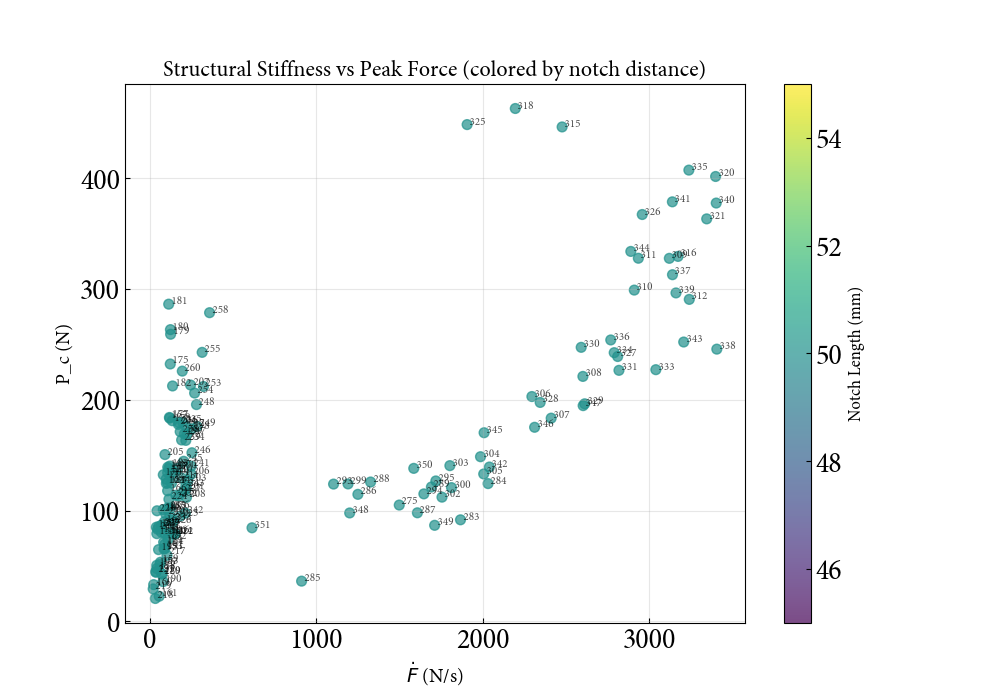

In [ ]:
import matplotlib.pyplot as plt

# Extract k, P_c y-values, notch distance d, and AFN
k_values = VS3PB_raw['F_dot']
P_c_y = VS3PB_raw['P_c'].apply(lambda x: x[1] if x is not None and isinstance(x, (list, tuple)) and len(x) == 2 else None)
d_values = VS3PB_raw['a']
afn_values = VS3PB_raw['AFN']

# Create plot with color gradient based on d
plt.figure(figsize=(10, 7))
scatter = plt.scatter(k_values, P_c_y, c=d_values, cmap='viridis', alpha=0.7, s=50)

# Add AFN labels next to each point
for i, afn in enumerate(afn_values):
    if k_values.iloc[i] is not None and P_c_y.iloc[i] is not None:
        plt.text(k_values.iloc[i], P_c_y.iloc[i], f' {afn}', fontsize=8, alpha=0.7)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Notch Length (mm)', fontsize=12)

plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)
plt.ylabel('P_c (N)', fontsize=14)
plt.title('Global Stiffness vs Peak Force (colored by notch distance)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
/var/folders/yw/0g80y5sj4vq46_yd4hg9kyjc0000gq/T/ipykernel_1322/684306617.py:44: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)


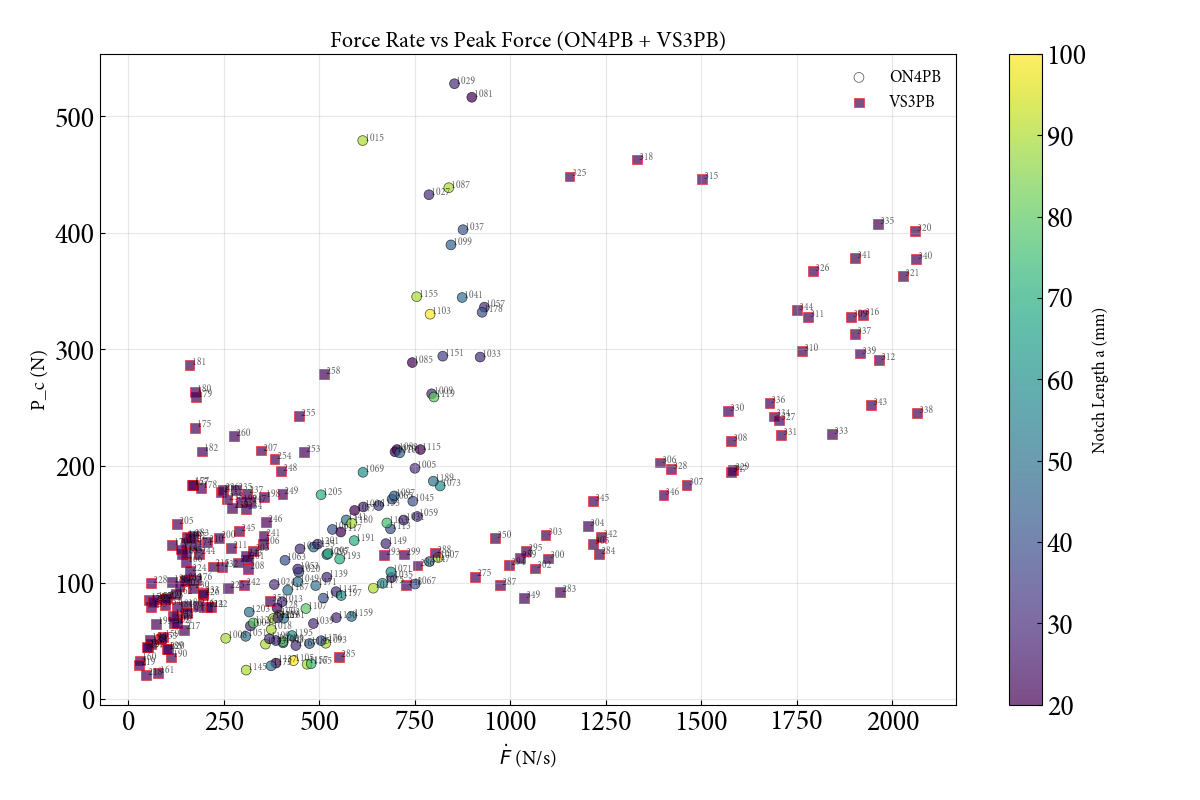

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract data from ON4PB
k_on4pb = ON4PB_raw['F_dot'] 
P_c_y_on4pb = ON4PB_raw['P_c'].apply(lambda x: x[1] if x is not None and isinstance(x, (list, tuple)) and len(x) == 2 else None)
d_on4pb = ON4PB_raw['a']
afn_on4pb = ON4PB_raw['AFN']

# Extract data from VS3PB
k_vs3pb = VS3PB_raw['k'] 
P_c_y_vs3pb = VS3PB_raw['P_c'].apply(lambda x: x[1] if x is not None and isinstance(x, (list, tuple)) and len(x) == 2 else None)
d_vs3pb = VS3PB_raw['a']
afn_vs3pb = VS3PB_raw['AFN']

# Create plot with color gradient based on d
plt.figure(figsize=(12, 8))

# Plot ON4PB data
scatter1 = plt.scatter(k_on4pb, P_c_y_on4pb, c=d_on4pb, cmap='viridis', alpha=0.7, s=50, 
                       marker='o', edgecolors='black', linewidths=0.5, label='ON4PB')

# Plot VS3PB data
scatter2 = plt.scatter(k_vs3pb, P_c_y_vs3pb, c=d_vs3pb, cmap='viridis', alpha=0.7, s=50, 
                       marker='s', edgecolors='red', linewidths=0.5, label='VS3PB')

# Add AFN labels next to each point for ON4PB
for i, afn in enumerate(afn_on4pb):
    if (k_on4pb.iloc[i] is not None and P_c_y_on4pb.iloc[i] is not None and 
        not pd.isna(afn)):
        plt.text(k_on4pb.iloc[i], P_c_y_on4pb.iloc[i], f' {int(afn)}', fontsize=7, alpha=0.6)

# Add AFN labels next to each point for VS3PB
for i, afn in enumerate(afn_vs3pb):
    if (k_vs3pb.iloc[i] is not None and P_c_y_vs3pb.iloc[i] is not None and 
        not pd.isna(afn)):
        plt.text(k_vs3pb.iloc[i], P_c_y_vs3pb.iloc[i], f' {int(afn)}', fontsize=7, alpha=0.6)

# Add colorbar
cbar = plt.colorbar(scatter1)
cbar.set_label('Notch Length a (mm)', fontsize=12)

plt.xlabel('$\dot{F}$ (N/s)', fontsize=14)
plt.ylabel('P_c (N)', fontsize=14)
plt.title('Force Rate vs Peak Force (ON4PB + VS3PB)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Fracture path 

**Crack Annotator Tool Overview**

The crack annotator is a custom Python tool developed for tracking and analysis of fracture propagation paths in notched beam specimens. 

**Coordinate System and Normalization:**
- Original coordinates are captured in image pixel space
- First crack point serves as the coordinate origin (0,0)
- Y-axis is oriented positive upwards for standard engineering convention
- Horizontal reference alignment corrects for specimen orientation variations

**Data Processing Pipeline:**
1. **Point Selection:** Interactive clicking defines crack path vertices
2. **Coordinate Capture:** Raw pixel coordinates are recorded
3. **Reference Alignment:** Horizontal reference line corrects specimen rotation
4. **Transformation:** Coordinates are normalized and rotated to standard orientation
5. **Output Generation:** Two files provide original and corrected coordinate data

**Image path:**
```python
print(raw_crack_paths_ON4PB+"/crack-1001.tiff")
```

**Command Execution:**
```bash
python crack_annotator.py "/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/crack-1001.tiff" --force
```

**Operational Procedure:**
1. **Drawing Mode Activation:** Press 'D' to enable point selection
2. **Path Definition:** Left-click sequential points along crack trajectory
3. **Path Completion:** Right-click to finalize crack path
4. **Data Persistence:** Original coordinates automatically saved
5. **Rotation Correction:** Optional alignment with horizontal reference
6. **Reference Selection:** Two-point horizontal line defines correction axis
7. **Final Processing:** Corrected coordinates generated and saved

**Output Data Structure:**
- **Original Coordinates:** `crack-1001_origin_line_coords.txt` - Raw pixel coordinates in image space
- **Corrected Coordinates:** `crack-1001_corrected_line_coords.txt` - Normalized coordinates with origin at crack initiation point, horizontal alignment, and positive y-axis orientation

### ON4PB

In [ ]:
# cracked image path 
print(raw_crack_paths_ON4PB+"/crack-1001.tiff")

/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/crack-1001.tiff
/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/crack-153.tiff


command ON4PB:

python crack_annotator.py "/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/crack-1117.tiff" --force

In [36]:
# Read all corrected crack coordinate files from a folder 
df_crack_coordinates_ON4PB = hlp.read_crack_annotator_output(raw_crack_paths_ON4PB, save_as="_crack_strikes")

Found 91 corrected coordinate files
Successfully read AFN 1001: 45 points
Successfully read AFN 1003: 36 points
Successfully read AFN 1004: 57 points
Successfully read AFN 1006: 58 points
Successfully read AFN 1007: 23 points
Successfully read AFN 1009: 36 points
Successfully read AFN 1011: 38 points
Successfully read AFN 1013: 58 points
Successfully read AFN 1015: 41 points
Successfully read AFN 1018: 31 points
Successfully read AFN 1020: 49 points
Successfully read AFN 1022: 37 points
Successfully read AFN 1027: 39 points
Successfully read AFN 1029: 44 points
Successfully read AFN 1031: 48 points
Successfully read AFN 1033: 39 points
Successfully read AFN 1035: 47 points
Successfully read AFN 1037: 38 points
Successfully read AFN 1039: 50 points
Successfully read AFN 1041: 33 points
Successfully read AFN 1043: 41 points
Successfully read AFN 1045: 41 points
Successfully read AFN 1047: 36 points
Successfully read AFN 1049: 30 points
Successfully read AFN 1051: 35 points
Successfully r

In [37]:
# Import the crack strikes file
df_crack_coordinates_ON4PB = dc.import_parquet(dc.get_data_path(ON4PB_path, 'crack_paths') + '/_crack_strikes.parquet')

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/_crack_strikes.parquet
Shape: (91, 5)
Columns: ['AFN', 'coordinates', 'num_points', 'file_path', 'crack_strike_direction_100px']


Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/_crack_strikes.parquet
Filtered to 91 valid crack paths
Using alpha=0.110 (pure indigo at 9 overlapping paths)
Crack heatmap created with 91 crack paths


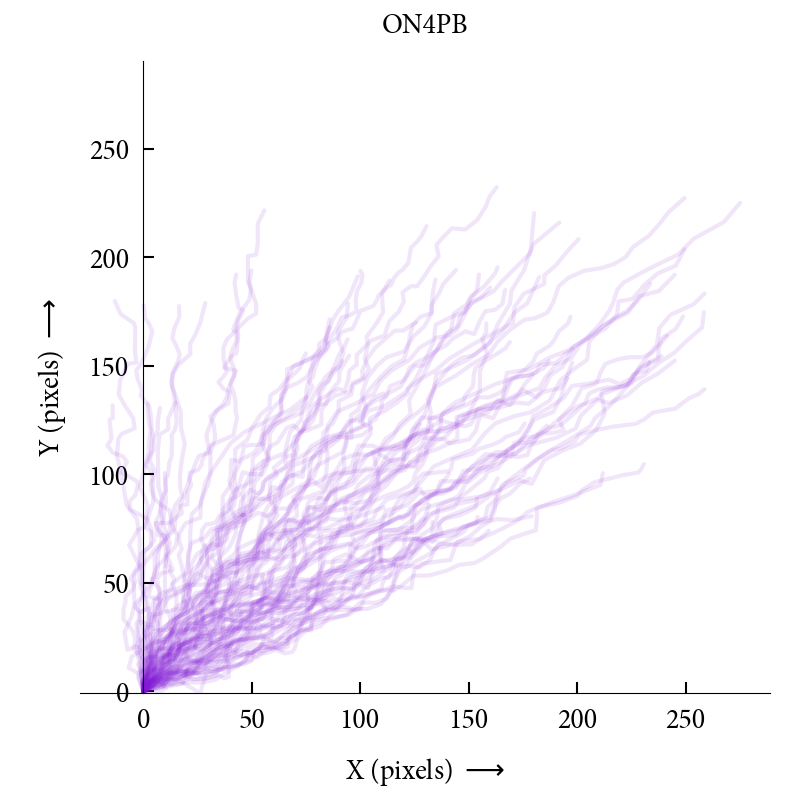

In [18]:
# Create heatmap directly from CSV
fig = vis.crack_heatmap(dc.get_data_path(ON4PB_path, 'crack_paths') + '/_crack_strikes.parquet', title="ON4PB")

In [164]:
# calculate and save crack directions
df_crack_strikes_and_directions = hlp.calculate_crack_direction(dc.get_data_path(ON4PB_path, 'crack_paths') + '/_crack_strikes.parquet',save_as='_crack_strikes_and_directions', target_lengths=[25,50,100,150,200])


Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/_crack_strikes.parquet
Filtered to 91 valid crack paths
Calculating crack directions for 25px target length...
Calculating crack directions for 50px target length...
Calculating crack directions for 100px target length...
Calculating crack directions for 150px target length...
Calculating crack directions for 200px target length...
Calculated crack strike directions for 5 target lengths: [25, 50, 100, 150, 200]
Saved DataFrame with crack directions to /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/_crack_strikes_and_directions.parquet (44678 bytes)


In [169]:
# Import the crack strikes and directions file
#dc.import_parquet(dc.get_data_path(ON4PB_path, 'crack_paths') + '/_crack_strikes_and_directions.parquet').head(1)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/crack_paths/_crack_strikes_and_directions.parquet
Filtered to 91 valid crack paths
Calculating crack directions for 100.0px target length...
Calculated crack strike directions for 1 target lengths: [100.0]
Creating stacked rose diagram with target lengths: [25, 100, 200]


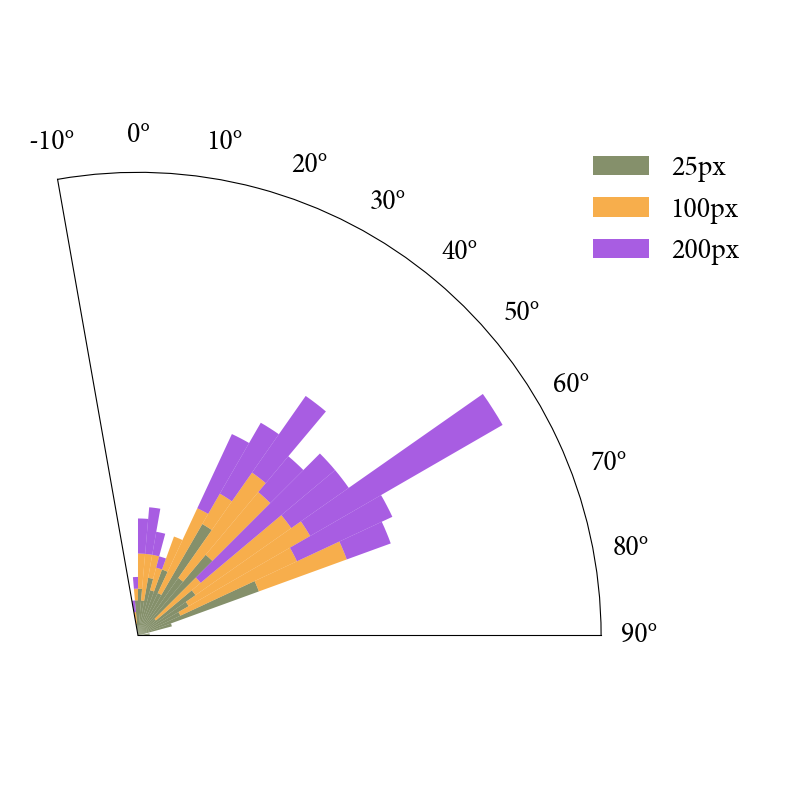

In [19]:
# Create rose diagram
fig = vis.crackpath_rose(hlp.calculate_crack_direction(dc.get_data_path(ON4PB_path, 'crack_paths') + '/_crack_strikes_and_directions.parquet'),target_length=[25,100,200], alpha=0.7)

### VS3PB

In [5]:
print(raw_crack_paths_VS3PB+"/crack-153.tiff")

/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/crack-153.tiff


command VS3PB:

python crack_annotator.py "/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/crack-153.tiff" --force

In [34]:
# Read all corrected crack coordinate files from a folder 
df_crack_coordinates_VS3PB = hlp.read_crack_annotator_output(raw_crack_paths_VS3PB, save_as="_crack_strikes")

Found 146 corrected coordinate files
Successfully read AFN 153: 37 points
Successfully read AFN 154: 49 points
Successfully read AFN 155: 47 points
Successfully read AFN 156: 62 points
Successfully read AFN 157: 31 points
Successfully read AFN 158: 48 points
Successfully read AFN 159: 68 points
Successfully read AFN 160: 97 points
Successfully read AFN 161: 60 points
Successfully read AFN 162: 48 points
Successfully read AFN 163: 60 points
Successfully read AFN 164: 56 points
Successfully read AFN 165: 38 points
Successfully read AFN 166: 41 points
Successfully read AFN 167: 23 points
Successfully read AFN 168: 32 points
Successfully read AFN 170: 39 points
Successfully read AFN 172: 69 points
Successfully read AFN 173: 54 points
Successfully read AFN 174: 47 points
Successfully read AFN 175: 63 points
Successfully read AFN 176: 58 points
Successfully read AFN 177: 36 points
Successfully read AFN 179: 46 points
Successfully read AFN 180: 52 points
Successfully read AFN 183: 67 points
S

In [35]:
# Import the crack strikes file
df_crack_coordinates_VS3PB = dc.import_parquet(dc.get_data_path(VS3PB_path, 'crack_paths') + '/_crack_strikes.parquet')

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/_crack_strikes.parquet
Shape: (146, 5)
Columns: ['AFN', 'coordinates', 'num_points', 'file_path', 'crack_strike_direction_100px']


Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/_crack_strikes.parquet
Filtered to 146 valid crack paths
Using alpha=0.068 (pure indigo at 15 overlapping paths)
Crack heatmap created with 146 crack paths


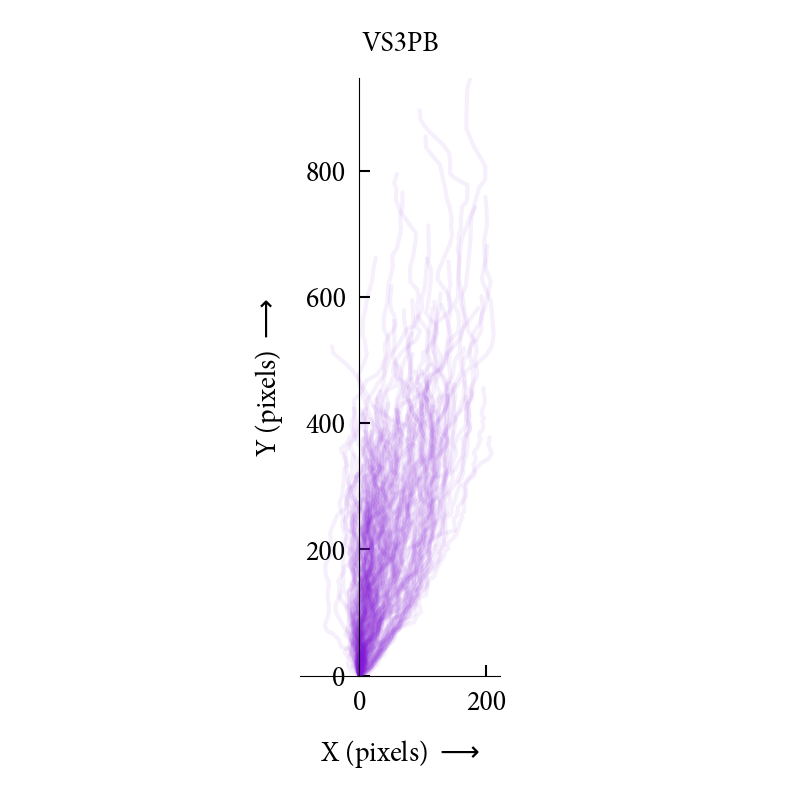

In [21]:
# Create heatmap directly from CSV
fig = vis.crack_heatmap(dc.get_data_path(VS3PB_path, 'crack_paths') + '/_crack_strikes.parquet', title="VS3PB")

In [22]:
# calculate and save crack directions
df_crack_strikes_and_directions_VS3PB = hlp.calculate_crack_direction(dc.get_data_path(VS3PB_path, 'crack_paths') + '/_crack_strikes.parquet',save_as='_crack_strikes_and_directions', target_lengths=[25,50,100,150,200, 300, 900])


Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/_crack_strikes.parquet
Filtered to 146 valid crack paths
Calculating crack directions for 25px target length...
Calculating crack directions for 50px target length...
Calculating crack directions for 100px target length...
Calculating crack directions for 150px target length...
Calculating crack directions for 200px target length...
Calculating crack directions for 300px target length...
Calculating crack directions for 900px target length...
Calculated crack strike directions for 7 target lengths: [25, 50, 100, 150, 200, 300, 900]
Saved DataFrame with crack directions to /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/_crack_strikes_and_directions.parquet (92405 bytes)


Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/crack_paths/_crack_strikes_and_directions.parquet
Filtered to 146 valid crack paths
Calculating crack directions for 100.0px target length...
Calculated crack strike directions for 1 target lengths: [100.0]
Creating stacked rose diagram with target lengths: [25, 200, 900]


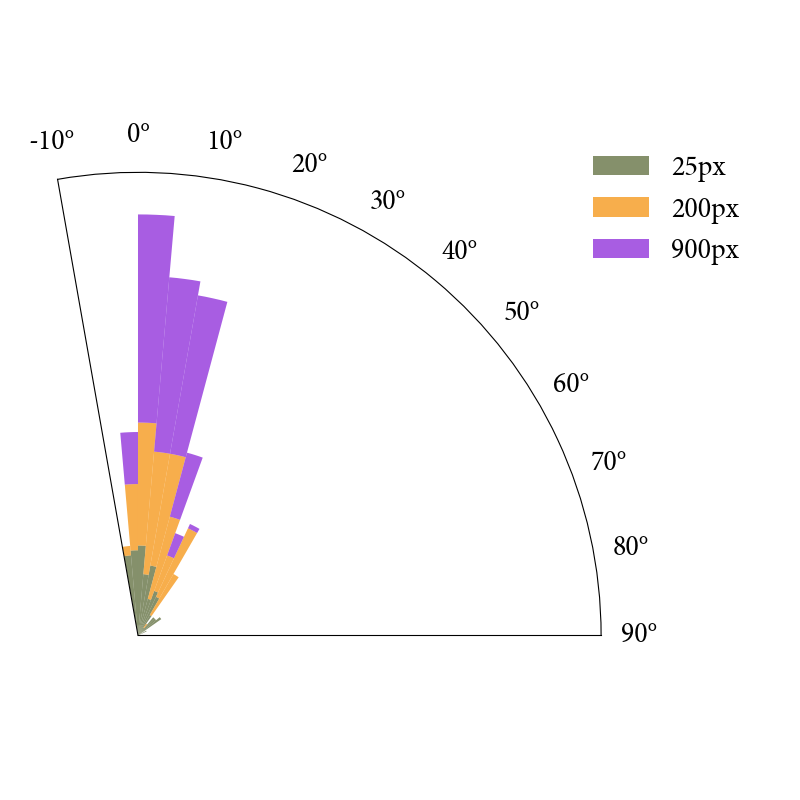

In [23]:
# Create rose diagram
fig = vis.crackpath_rose(hlp.calculate_crack_direction(dc.get_data_path(VS3PB_path, 'crack_paths') + '/_crack_strikes_and_directions.parquet'),target_length=[25, 200, 900], alpha=0.7)

## 4. Digital Image Correlation 

### 4.1 Camera calibration

In [1]:
# Calibrate iPhone camera was run already 
# iphone_calib = ip.calibrate_camera_from_checkerboard(
#     video_calibration_path+'/cal-Iphone',
#     checkerboard_size=(9, 6),
#     visualize=True,  # Set True to see corner detection
#     save_detected_corners=True, # save images with detected corners
#     target_resolution=(3840, 2160) # target resolution for calibration (checkerboard in 1920x1080 HD)
# )
# Saves to: cal-Iphone_params.npz and cal-Iphone_detected_corners

In [2]:
# Calibrate Sony camera was run already
# sony_calib = ip.calibrate_camera_from_checkerboard(
#     video_calibration_path+'/cal-sony',
#     checkerboard_size=(9, 6),
#     visualize=True,
#     save_detected_corners=True # save images with detected corners
# )
# Saves to: cal-sony_params.npz and cal-sony_detected_corners

In [ ]:
# Undistort images for VS3PB was run on external computer already 
# results_distortion_correction_VS3PB = ip.apply_distortion_correction(
#     frames_folder_path=raw_videos_path_VS3PB,
#     iphone_npz_path=video_calibration_path+'/cal-Iphone_params.npz',
#     sony_npz_path=video_calibration_path+'/cal-sony_params.npz',
#     output_suffix="_undistorted",
#     visualize=True,
#     force_overwrite=False,
#     max_workers=8,
# )

In [ ]:
# Undistort images for ON4PB was run on external computer already 
# results_distortion_correction_ON4PB = ip.apply_distortion_correction(
#     frames_folder_path=raw_videos_path_ON4PB,
#     iphone_npz_path=video_calibration_path+'/cal-Iphone_params.npz',
#     sony_npz_path=video_calibration_path+'/cal-sony_params.npz',
#     output_suffix="_undistorted",
#     visualize=True,
#     force_overwrite=False,
#     max_workers=8,
# )

In [ ]:
# Undistort reference images ON4PB (individual images in one folder -> images mode)
results_ref_images_ON4PB = ip.apply_distortion_correction(
    frames_folder_path=ref_pictures_path_ON4PB,
    iphone_npz_path=video_calibration_path+'/cal-Iphone_params.npz',
    sony_npz_path=video_calibration_path+'/cal-sony_params.npz',
    output_suffix="_undistorted",
    visualize=True,
    force_overwrite=False,
    max_workers=4,
    mode="images"  # New mode for individual images
)

Applying Distortion Correction to Experimental Images
Mode: images
Frames folder: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/ref_pictures
iPhone calibration: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/video_calibration/cal-Iphone_params.npz
Sony calibration: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/video_calibration/cal-sony_params.npz
Output suffix: _undistorted
Force overwrite: False

✓ Both calibration files found
✓ Found 5 image files
Processing ref-25-01-20.tiff...
  ✓ Detected sony camera (1920x1080)
  ✓ Loaded calibration parameters for sony
  ✓ Successfully processed ref-25-01-20.tiff
Processing ref-25-01-21.tiff...
  ✓ Detected sony camera (1920x1080)
  ✓ Loaded calibration parameters for sony
  ✓ Successfully processed ref-25-01-21.tiff
Processing ref-25-01-22.tiff...
  ✓ Detected sony camera (1920x1080)
  ✓ Loaded calibration parameters for sony
  ✓ Successfully processed ref-25-01-22

In [ ]:
# Undistort reference images VS3PB (individual images in one folder -> images mode)
results_ref_images_VS3PB = ip.apply_distortion_correction(
    frames_folder_path=ref_pictures_path_VS3PB,
    iphone_npz_path=video_calibration_path+'/cal-Iphone_params.npz',
    sony_npz_path=video_calibration_path+'/cal-sony_params.npz',
    output_suffix="_undistorted",
    visualize=True,
    force_overwrite=False,
    max_workers=4,
    mode="images"  # Mode for individual images
)

Applying Distortion Correction to Experimental Images
Mode: images
Frames folder: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/ref_pictures
iPhone calibration: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/video_calibration/cal-Iphone_params.npz
Sony calibration: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/video_calibration/cal-sony_params.npz
Output suffix: _undistorted
Force overwrite: False

✓ Both calibration files found
✓ Found 7 image files
Processing ref-24-03-08.tiff...
  ✓ Detected sony camera (1920x1080)
  ✓ Loaded calibration parameters for sony
  ✓ Successfully processed ref-24-03-08.tiff
Processing ref-24-03-11.tiff...
  ✓ Detected iphone camera (3840x2160)
  ✓ Loaded calibration parameters for iphone
  ✓ Successfully processed ref-24-03-11.tiff
Processing ref-24-03-14_195.tiff...
  ✓ Detected iphone camera (3840x2160)
  ✓ Loaded calibration parameters for iphone
  ✓ Successfully processed 

In [ ]:
video_calibration_path+'/cal-Iphone'

'/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/video_calibration/cal-Iphone'

### 4.2 Geometry selection 

**Apply Rotation Correction to Undistorted Images**

**Note:** Run AFTER distortion correction. Distortion parameters are orientation-specific.

Rotation preserves exact pixel dimensions (same resolution). Pixel-to-mm conversion remains valid because pixel size is unchanged. Black corners/edges are expected.

**Output:** Creates `AFN_undistorted_rotcor_frames` folders with rotated images (same filenames, same resolution).

In [14]:
# Apply rotation correction
# Function searches for: *_undistorted_frames folders
# Reads rotation correction (in radians) from master parquet
# Creates: *_undistorted_rotcor_frames folders

# ON4PB
# dc.apply_rotation_correction(
#     frames_folder_path=raw_videos_path_ON4PB,
#     master_parquet_path=raw_metadata_path_ON4PB+"/ON4PB_raw.parquet",
#     max_workers=8,
#     force_overwrite=False  # Skip already processed folders
# )


In [15]:
# VS3PB
# dc.apply_rotation_correction(
#     frames_folder_path=raw_videos_path_VS3PB,
#     master_parquet_path=raw_metadata_path_VS3PB+"/VS3PB_raw.parquet",
#     max_workers=8,
#     force_overwrite=True  # Skip already processed folders
# )

Define metadata for sample_geometry_raw column in info Parquet file

In [ ]:
# Define metadata for sample_geometry_raw column in info Parquet file
new_metadata = {
    'sample_geometry_raw': {
        'units': 'pixels',
        'data_type': 'List',
        'long_name': 'raw geometry data tracked from pictures',
        'description': '''Raw sample geometry coordinates collected from undistorted images using the vertex_annotator tool. 
Data are stored as pixel coordinates (x, y) in a list format. 

Point orders and definitions:

VS3PB (3-point bend) - 9 points total:
1. notch_tip: Crack tip location
2. notch_start: Bottom of notch (crack start)
3. left_support: Left lower support point
4. left_lower_vertex: Left bottom corner of sample
5. left_upper_vertex: Left top corner of sample
6. force_roller: Top roller where force is applied
7. right_upper_vertex: Right top corner of sample
8. right_lower_vertex: Right bottom corner of sample
9. right_support: Right lower support point

ON4PB (4-point bend) - 11 points total:
1. notch_tip: Crack tip location
2. notch_start: Bottom of notch (crack start)
3. left_support: Left lower support point
4. left_lower_vertex: Left bottom corner of sample
5. left_upper_vertex: Left top corner of sample
6. left_roller: Left upper roller (F_1)
7. right_roller: Right upper roller (F_2)
8. right_upper_vertex: Right top corner of sample
9. right_lower_vertex: Right bottom corner of sample
10. right_support: Right lower support point
11. force_pin: Force sensor pin contact point (for horizontal alignment)

These coordinates will be used as input for FE model generation and DIC region of interest definition.'''
    }
}

# Add column and metadata to both data and info Parquet files for ON4PB
# df_data, df_info = dc.add_columns_to_data(
#     raw_data_path=raw_metadata_path_ON4PB+'/ON4PB_raw.parquet',
#     raw_info_data_path=raw_metadata_path_ON4PB+'/ON4PB_raw_info.parquet',
#     new_columns_info=new_metadata,
#     appendix='',  # No appendix - update existing files
#     save=True
# )

# Add column and metadata to both data and info Parquet files for VS3PB
# df_data, df_info = dc.add_columns_to_data(
#     raw_data_path=raw_metadata_path_VS3PB+'/VS3PB_raw.parquet',
#     raw_info_data_path=raw_metadata_path_VS3PB+'/VS3PB_raw_info.parquet',
#     new_columns_info=new_metadata,
#     appendix='',
#     save=True
# )

Loaded data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Loaded metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Added column: sample_geometry_raw

Successfully added new columns: ['sample_geometry_raw']
Added metadata for: sample_geometry_raw
Saved successfully:
  - Data: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet (7186054 bytes)
  - Metadata: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet (6214 bytes)

Summary: Added 1 new columns
Loaded data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Loaded metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Added column: sample_geometry_raw

Successfully

In [12]:
# Define metadata for sample_geometry_FEM column in info Parquet file
# This column contains FE model input coordinates derived from sample_geometry_raw
# Points are transformed to mm coordinates with notch_tip as origin (0, 0)

new_metadata = {
    'sample_geometry_FEM': {
        'units': 'mm',
        'data_type': 'List',
        'long_name': 'FE model geometry coordinates with notch tip as origin',
        'description': '''FE (Finite Element) model input geometry coordinates derived from 
sample_geometry_raw by coordinate transformation and unit conversion.

Transformation rules:
1. The notch_tip point (first point in sample_geometry_raw) becomes the origin (0, 0) in mm
2. All other points are translated relative to this new origin
3. All coordinates are converted from pixels to mm using the 'pixel convertation' factor
4. Coordinate system: x positive to the right, y positive upward

Point orders and definitions (same as sample_geometry_raw, but in mm with notch_tip as origin):

VS3PB (3-point bend) - 9 points total:
1. notch_tip: Origin (0, 0) mm
2. notch_start: Bottom of notch (crack start) - relative to notch_tip
3. left_support: Left lower support point - relative to notch_tip
4. left_lower_vertex: Left bottom corner of sample - relative to notch_tip
5. left_upper_vertex: Left top corner of sample - relative to notch_tip
6. force_roller: Top roller where force is applied - relative to notch_tip
7. right_upper_vertex: Right top corner of sample - relative to notch_tip
8. right_lower_vertex: Right bottom corner of sample - relative to notch_tip
9. right_support: Right lower support point - relative to notch_tip

ON4PB (4-point bend) - 11 points total:
1. notch_tip: Origin (0, 0) mm
2. notch_start: Bottom of notch (crack start) - relative to notch_tip
3. left_support: Left lower support point - relative to notch_tip
4. left_lower_vertex: Left bottom corner of sample - relative to notch_tip
5. left_upper_vertex: Left top corner of sample - relative to notch_tip
6. left_roller: Left upper roller (F_1) - relative to notch_tip
7. right_roller: Right upper roller (F_2) - relative to notch_tip
8. right_upper_vertex: Right top corner of sample - relative to notch_tip
9. right_lower_vertex: Right bottom corner of sample - relative to notch_tip
10. right_support: Right lower support point - relative to notch_tip
11. force_pin: Force sensor pin contact point (for horizontal alignment) - relative to notch_tip

All coordinates are stored as (x, y) tuples in mm in list format.
These coordinates are used as input for FE model generation (e.g., Abaqus).'''
    }
}

# Add column and metadata to both data and info Parquet files for ON4PB
# df_data, df_info = dc.add_columns_to_data(
#     raw_data_path=raw_metadata_path_ON4PB+'/ON4PB_raw.parquet',
#     raw_info_data_path=raw_metadata_path_ON4PB+'/ON4PB_raw_info.parquet',
#     new_columns_info=new_metadata,
#     appendix='',  # No appendix - update existing files
#     save=True
# )

# Add column and metadata to both data and info Parquet files for VS3PB
# df_data, df_info = dc.add_columns_to_data(
#     raw_data_path=raw_metadata_path_VS3PB+'/VS3PB_raw.parquet',
#     raw_info_data_path=raw_metadata_path_VS3PB+'/VS3PB_raw_info.parquet',
#     new_columns_info=new_metadata,
#     appendix='',
#     save=True
# )

Loaded data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Loaded metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet

DATA SAFETY WARNING:
   The following columns already exist and will NOT be overwritten:
   - sample_geometry_FEM
   If you need to update these columns, consider using merge_load_and_analysis_data() instead.
   This prevents accidental loss of analysis results from load_signal_analyser.py
Updated metadata for: sample_geometry_FEM
Saved successfully:
  - Data: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet (7187530 bytes)
  - Metadata: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet (7742 bytes)

Summary: Added 1 new columns
Loaded data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/me

In [16]:
# Define metadata for measured geometry dimensions from vertex annotator
# These dimensions are calculated from sample_geometry_raw pixel coordinates
# and converted to mm using the 'pixel convertation' factor
# VS3PB (3-point bend) point order: 
# 0=notch_tip, 1=notch_start, 2=left_support, 3=left_lower_vertex, 
# 4=left_upper_vertex, 5=force_roller, 6=right_upper_vertex, 
# 7=right_lower_vertex, 8=right_support

new_metadata = {
    'l_s_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured span length',
        'description': '''Measured span length (total support-to-support distance) 
for 3-point bend test, calculated as l_s_meas = l_f_meas + l_v_meas.
This is the total horizontal distance between the left and right supports,
measured from sample_geometry_raw pixel coordinates and converted to mm using 
'pixel convertation'.'''
    },
    'l_f_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured distance from notch to right support',
        'description': '''Measured horizontal (x) distance from notch_start (point 1) 
to fixed right_support (point 8) in 3-point bend configuration.
Calculated as |x8 - x1| in mm from sample_geometry_raw coordinates.'''
    },
    'l_v_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured distance from notch to left support',
        'description': '''Measured horizontal (x) distance from notch_start (point 1) 
to variable left_support (point 2) in 3-point bend configuration.
Calculated as |x1 - x2| in mm from sample_geometry_raw coordinates.'''
    },
    'h_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured sample height',
        'description': '''Measured sample height (vertical dimension) calculated as 
the average of left and right side heights.
Left height: |y4 - y3| (vertical distance between left_upper_vertex and left_lower_vertex).
Right height: |y6 - y7| (vertical distance between right_upper_vertex and right_lower_vertex).
h_meas = (|y4 - y3| + |y6 - y7|) / 2, converted to mm from sample_geometry_raw coordinates.'''
    },
    'a_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured notch depth',
        'description': '''Measured notch length calculated as the vertical 
(y) distance from notch_tip (point 0) to notch_start (point 1).
Calculated as |y0 - y1| in mm from sample_geometry_raw coordinates.'''
    },
    'l_P_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured horizontal offset of force roller from notch start',
        'description': '''Measured horizontal (x) offset of force_roller (point 5) relative 
to notch_start (point 2). Calculated as x5 - x2 in mm from sample_geometry_raw coordinates.
Can be negative if the force roller is to the left of the notch start, or positive if to the right.'''
    },
    'w_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured sample width',
        'description': '''Measured sample width (horizontal dimension) calculated as the 
average of upper and lower widths.
Upper width: |x4 - x6| (horizontal distance between left_upper_vertex and right_upper_vertex).
Lower width: |x3 - x7| (horizontal distance between left_lower_vertex and right_lower_vertex).
w_meas = (|x4 - x6| + |x3 - x7|) / 2, converted to mm from sample_geometry_raw coordinates.'''
    }
}

# Use this to add columns and metadata to parquet files:
# 
# 
# # For VS3PB
df_data, df_info = dc.add_columns_to_data(
    raw_data_path=raw_metadata_path_VS3PB+'/VS3PB_raw.parquet',
    raw_info_data_path=raw_metadata_path_VS3PB+'/VS3PB_raw_info.parquet',
    new_columns_info=new_metadata,  # Use new_metadata for basic measurements
    appendix='',  # No appendix - update existing files
    save=True
)

Loaded data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Loaded metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Added column: l_s_meas
Added column: l_f_meas
Added column: l_v_meas
Added column: h_meas
Added column: a_meas
Added column: l_P_meas
Added column: w_meas

Successfully added new columns: ['l_s_meas', 'l_f_meas', 'l_v_meas', 'h_meas', 'a_meas', 'l_P_meas', 'w_meas']
Added metadata for: l_s_meas
Added metadata for: l_f_meas
Added metadata for: l_v_meas
Added metadata for: h_meas
Added metadata for: a_meas
Added metadata for: l_P_meas
Added metadata for: w_meas
Saved successfully:
  - Data: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet (24636993 bytes)
  - Metadata: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet (8243 byt

In [17]:
# Define metadata for measured geometry dimensions from vertex annotator
# These dimensions are calculated from sample_geometry_raw pixel coordinates
# and converted to mm using the 'pixel convertation' factor
# ON4PB (4-point bend) point order: 
# 0=notch_tip, 1=notch_start, 2=left_support, 3=left_lower_vertex, 
# 4=left_upper_vertex, 5=left_roller, 6=right_roller, 7=right_upper_vertex, 
# 8=right_lower_vertex, 9=right_support, 10=force_pin

new_metadata = {
    'l_1_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured short roller span',
        'description': '''Short roller span calculated by average horizontal distance 
of notch_start (point 1) to left_support (point 2) and notch_start (point 1) to 
right_roller (point 6). Calculated as (|x1 - x2| + |x1 - x6|) / 2 in mm from 
sample_geometry_raw coordinates.'''
    },
    'l_2_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured long roller span',
        'description': '''Long roller span calculated via average of notch_start (point 1) 
to left_roller (point 5) and notch_start (point 1) to right_support (point 9). 
Calculated as (|x1 - x5| + |x1 - x9|) / 2 in mm from sample_geometry_raw coordinates.'''
    },
    'w_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured sample width',
        'description': '''Measured sample width calculated by average of both upper vertex 
distances and both lower vertex distances.
Upper width: |x4 - x7| (horizontal distance between left_upper_vertex and right_upper_vertex).
Lower width: |x3 - x8| (horizontal distance between left_lower_vertex and right_lower_vertex).
w_meas = (|x4 - x7| + |x3 - x8|) / 2, converted to mm from sample_geometry_raw coordinates.'''
    },
    'h_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured sample height',
        'description': '''Measured sample height calculated by average vertical (y) distance 
of both left vertices and both right vertices.
Left vertical distance: |y4 - y3| (vertical distance between left_upper_vertex and left_lower_vertex).
Right vertical distance: |y7 - y8| (vertical distance between right_upper_vertex and right_lower_vertex).
h_meas = (|y4 - y3| + |y7 - y8|) / 2, converted to mm from sample_geometry_raw coordinates.'''
    },
    'a_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured notch depth',
        'description': '''Measured notch length calculated as the vertical (y) distance 
from notch_tip (point 0) to notch_start (point 1). Calculated as |y0 - y1| in mm 
from sample_geometry_raw coordinates.'''
    },
    'l_P_meas': {
        'units': 'mm',
        'data_type': 'Float',
        'long_name': 'measured horizontal offset of force pin from notch start',
        'description': '''Offset of the force from notch_start (point 1) horizontally, 
as in 3PB configuration. Calculated as x10 - x1 in mm from sample_geometry_raw coordinates.
Can be negative if the force pin is to the left of the notch start, or positive if to the right.'''
    },
    'P1toP2_meas': {
        'units': 'None',
        'data_type': 'Float',
        'long_name': 'measured ratio for dividing force P into P1 and P2',
        'description': '''Ratio of horizontal distance of left_roller (point 5) to force_pin 
(point 10) divided by distance of force_pin (point 10) to right_roller (point 6). 
Calculated as |x5 - x10| / |x10 - x6| in mm from sample_geometry_raw coordinates.
This ratio is needed for later dividing the total force P into P1 and P2 acting at 
the both upper rollers (left_roller and right_roller).'''
    }
}

# Use this to add columns and metadata to parquet files:
# 
# import data_config as dc
# 
# # For ON4PB
df_data, df_info = dc.add_columns_to_data(
    raw_data_path=raw_metadata_path_ON4PB+'/ON4PB_raw.parquet',
    raw_info_data_path=raw_metadata_path_ON4PB+'/ON4PB_raw_info.parquet',
    new_columns_info=new_metadata,
    appendix='',  # No appendix - update existing files
    save=True
)

Loaded data from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Loaded metadata from: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Added column: l_1_meas
Added column: l_2_meas
Added column: w_meas
Added column: h_meas
Added column: a_meas
Added column: l_P_meas
Added column: P1toP2_meas

Successfully added new columns: ['l_1_meas', 'l_2_meas', 'w_meas', 'h_meas', 'a_meas', 'l_P_meas', 'P1toP2_meas']
Added metadata for: l_1_meas
Added metadata for: l_2_meas
Added metadata for: w_meas
Added metadata for: h_meas
Added metadata for: a_meas
Added metadata for: l_P_meas
Added metadata for: P1toP2_meas
Saved successfully:
  - Data: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet (7188760 bytes)
  - Metadata: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet (

In [9]:
raw_videos_path_ON4PB

'/Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/video_fracture_and_preload'

**use vertex annotator tool on ON4PB:** </br>
python vertex_annotator.py ON4PB </br>
add *--limit 3* for developer loading faster 

**use vertex annotator tool on VS3PB:** </br>
python vertex_annotator.py ON4PB 

In [21]:
ON4PB_raw = dc.import_parquet(raw_metadata_path_ON4PB+"/ON4PB_raw.parquet")
display(ON4PB_raw.head(6))
ON4PB_raw_info = dc.import_parquet(raw_metadata_path_ON4PB+"/ON4PB_raw_info.parquet")
display(ON4PB_raw_info)

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw.parquet
Shape: (107, 53)
Columns: ['AFN', 'date', 'v', 'h', 'LOI', 'letterslot', 'notch percentage', 'combination', 'd', 'a', 'rho_1', 'rho_2', 'rho', 'preload', 'start preload', 'end preload', 'P_pre', 'quality of preload', 'exp start', 'exp end', 'peak number', 'P_e', 'quality', 'success', 'note', 'crack growth', 'gearbox', 'motor Unit', 'shear speed', 'motor speed', 'samples per mm', 'offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot', 'T_s', 'sample_geometry_raw', 'camera', 'pixel convertation', 'rotation correction', 'sample_geometry_FEM', 'w_data', 'P_data', 'l_1_meas', 'l_2_meas', 'w_meas', 'h_meas', 'a_meas', 'l_P_meas', 'P1toP2_meas']


,AFN,date,v,h,LOI,letterslot,notch percentage,combination,d,a,rho_1,rho_2,rho,preload,start preload,end preload,P_pre,quality of preload,exp start,exp end,peak number,P_e,quality,success,note,crack growth,gearbox,motor Unit,shear speed,motor speed,samples per mm,offset_region,P_off,start_lin,end_lin,k,P_c,F_dot,T_s,sample_geometry_raw,camera,pixel convertation,rotation correction,sample_geometry_FEM,w_data,P_data,l_1_meas,l_2_meas,w_meas,h_meas,a_meas,l_P_meas,P1toP2_meas
0,1001,2025-01-20,1650,125,U,A,1,A1,0.0,90.0,337.0,336.0,336.50,0,None,None,NaN,2,00:37:00,00:42:00,0,71.930,0,True,REF,1,111,1,1650,240,1210,"[0.0314, 14.0306]",2.737738,"[15.5967, 55.7906]","[15.6595, 70.7809]",238.699045,"[15.6868, 71.9294]",393.853424,-6.6,"[[952.125, 460.125], [957.75, 708.75], [684.37...",sony,0.370174,0.0,"[[0.0, -0.0], [2.0822276755042304, -92.0344632...","[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[0.0, 2.5991, 2.5991, 2.5689, 2.5991, 2.6294, ...",None,None,None,None,None,None,None
1,1003,2025-01-20,1650,125,U,A,1,A1,0.0,90.0,301.0,302.0,301.50,0,None,None,NaN,2,00:14:00,00:19:00,0,62.803,0,True,None,1,111,1,1650,240,1210,"[0.0, 11.3]",3.823118,"[13.2397, 45.0617]","[13.3248, 61.5329]",193.551116,"[13.3413, 62.8022]",319.359342,-6.7,None,sony,0.370174,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8382, 3.8685, 3.8685, 3.8685, 3.8382, 3.868...",None,None,None,None,None,None,None
2,1004,2025-01-20,1650,125,U,A,.8,A.8,0.0,30.0,315.0,315.0,315.00,0,None,None,NaN,2,00:19:00,00:29:00,0,198.020,1,True,In videos supports are crushing a lot,1,111,1,1650,240,1210,"[0.0, 13.8438]",3.851033,"[21.7926, 126.1182]","[21.9207, 184.3569]",454.634660,"[21.9612, 198.0174]",750.147190,-6.8,None,sony,0.370174,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8382, 3.8382, 3.8382, 3.8685, 3.8685, 3.868...",None,None,None,None,None,None,None
3,1005,2025-01-20,1650,125,U,A,.8,A.8,0.0,30.0,NaN,NaN,NaN,0,None,None,NaN,2,None,None,<NA>,164.924,2,False,"REF, cracked over left lower support from top ...",1,111,1,1650,240,1210,"[0.0, 18.6893]",3.915756,"[26.6818, 93.8104]","[26.8628, 161.2971]",372.854696,"[26.8769, 164.9238]",615.210249,NaN,None,sony,0.370174,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8685, 3.8685, 3.8382, 3.8382, 3.8685, 3.838...",None,None,None,None,None,None,None
4,1006,2025-01-20,1650,125,U,A,.8,A.8,0.0,30.0,318.0,293.0,305.50,0,None,None,NaN,2,00:09:00,00:15:00,0,121.524,1,True,"lot of crushing, crack opening together with s...",1,111,1,1650,240,1210,"[0.0, 6.7]",3.867156,"[11.6702, 86.9802]","[11.7331, 117.8977]",491.534181,"[11.7413, 121.5244]",811.031399,-6.1,None,sony,0.370174,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8382, 3.8685, 3.8685, 3.8685, 3.8685, 3.838...",None,None,None,None,None,None,None
5,1007,2025-01-20,1650,125,D,A,1,A1,0.0,90.0,365.5,362.0,363.75,0,None,None,NaN,2,00:20:00,00:25:00,0,52.224,0,True,The linear loading path is very short so the s...,1,111,1,1650,240,1210,"[0.0, 8.824]",3.868681,"[9.9612, 45.2128]","[10.0058, 52.1035]",154.500000,"[10.0066, 52.2244]",254.925000,-4.1,None,sony,0.370174,0.0,None,"[0.0, 0.0008, 0.0017, 0.0025, 0.0033, 0.0041, ...","[3.8685, 3.8685, 3.8685, 3.8987, 3.8685, 3.868...",None,None,None,None,None,None,None


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/ON4PB/metadata/ON4PB_raw_info.parquet
Shape: (53, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
0,AFN,None,Integer,automated file number,Automated file number saved from motor untit a...
1,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...
2,LOI,None,"String: U, L",Layer of interest,Upper (U) or Lower (L) layer of interest
3,P1toP2_meas,None,Float,measured ratio for dividing force P into P1 an...,Ratio of horizontal distance of left_roller (p...
4,P_c,N,Coordinates as Tuple,critical fracture Force,critical force at the time of the crack onset
5,P_data,N,List,force,force signal of the load cell
6,P_e,N,Float,critical fracture Force estimate,The force was red manually out of the plot wit...
7,P_off,N,Float,offset of the load cell,offset which was calculated on the signal duri...
8,P_pre,N,Float,critical fracture Force estimate,The force was red manually out of the plot wit...
9,T_s,◦C,Float,Sample Temperature,Post experimental emperature in the middle of ...


In [27]:
VS3PB_raw = dc.import_parquet(raw_metadata_path_VS3PB+"/VS3PB_raw.parquet")
display(VS3PB_raw.head(6))
VS3PB_raw_info = dc.import_parquet(raw_metadata_path_VS3PB+"/VS3PB_raw_info.parquet")
display(VS3PB_raw_info)

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw.parquet
Shape: (158, 45)
Columns: ['AFN', 'date', 'v', 'l_s', 'l_v', 'l_f', 'l_P', 'a', 'rho_1', 'rho_2', 'rho', 'P_c', 'peak number', 'exp start', 'exp end', 'quality', 'success', 'crack growth', 'note', 'gearbox', 'motor Unit', 'motor speed', 'samples per mm', 'start_lin', 'end_lin', 'k', 'offset_region', 'P_off', 'F_dot', 'T_s', 'sample_geometry_raw', 'camera', 'pixel convertation', 'rotation correction', 'sample_geometry_FEM', 'w_data', 'P_data', 'l_s_meas', 'l_f_meas', 'l_v_meas', 'h_meas', 'a_meas', 'l_P_meas', 'w_meas', 'rigid_ref_region']


,AFN,date,v,l_s,l_v,l_f,l_P,a,rho_1,rho_2,rho,P_c,peak number,exp start,exp end,quality,success,crack growth,note,gearbox,motor Unit,motor speed,samples per mm,start_lin,end_lin,k,offset_region,P_off,F_dot,T_s,sample_geometry_raw,camera,pixel convertation,rotation correction,sample_geometry_FEM,w_data,P_data,l_s_meas,l_f_meas,l_v_meas,h_meas,a_meas,l_P_meas,w_meas,rigid_ref_region
0,153,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,256.0,249.0,252.5,NaN,10,00:57:00,01:12:00,0,True,0,on that day we had a 75mm diameter rod at the ...,3052,1,2795.0,3327.0,"[11.306, 38.8812]","[11.4349, 49.7764]",84.524438,"[0.0, 5.0565]",1.905741,59.167106,-3.9,"[[954.375, 796.5], [954.375, 963.0], [291.7500...",sony,0.306321,0.019787,"[[0.0, -0.0], [0.0, -51.0024130039664], [-202....","[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[1.9947, 2.0098, 2.0249, 2.0249, 2.0249, 2.009...",None,None,None,None,None,None,None,"[[686.625, 987.75], [816.0, 1060.875]]"
1,154,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,274.0,263.0,268.5,NaN,5,00:16:00,00:27:00,0,True,0,REF. Looked like it was exactly cracking at th...,3052,1,2795.0,3327.0,"[4.364, 54.4457]","[4.6201, 79.2735]",96.945724,"[0.0, 0.2381]",1.980505,67.862007,-4.1,"[[951.0, 846.0], [948.75, 967.5], [279.3750000...",sony,0.306321,0.019787,"[[0.0, -0.0], [-0.6892217973508973, -37.217977...","[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0098, 2.0098, 2.0249, 1.9947, 1.9947, 2.009...",None,None,None,None,None,None,None,None
2,155,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,267.0,270.0,268.5,NaN,5,00:22:00,00:31:00,0,True,0,REF,3052,1,2795.0,3327.0,"[3.1861, 70.5845]","[3.3297, 78.9712]",58.403203,"[0.0, 0.1755]",2.059131,40.882242,-4.5,None,sony,0.306321,0.019787,None,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0249, 2.04, 2.0249, 2.0249, 2.04, 2.04, 2.0...",None,None,None,None,None,None,None,None
3,156,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,272.0,274.0,273.0,NaN,3,00:17:00,00:26:00,0,True,0,REF. Looked like it was exactly cracking at th...,3052,1,2795.0,3327.0,"[3.9739, 78.5783]","[4.0878, 84.7135]",53.864794,"[0.0, 0.2071]",2.006102,37.705356,-4.2,None,sony,0.306321,0.019787,None,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0098, 2.0098, 1.9947, 2.0098, 2.0098, 2.009...",None,None,None,None,None,None,None,None
4,157,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,274.0,269.0,271.5,NaN,2,00:11:00,00:22:00,0,True,0,sample left for 1h so it was warmer compared t...,3052,1,2795.0,3327.0,"[4.346, 73.0325]","[4.5089, 85.0157]",73.561694,"[0.0, 0.2504]",2.031128,51.493186,-3.8,None,sony,0.306321,0.019787,None,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0249, 2.0249, 2.04, 2.0249, 2.0098, 2.0249,...",None,None,None,None,None,None,None,None
5,158,2024-03-08,700.0,400.0,200.0,200.0,0.0,50.0,270.0,272.0,271.0,NaN,3,00:10:00,00:18:00,1,True,0,Sun was shining on sample and the inc is float...,3052,1,2795.0,3327.0,"[2.7039, 35.4358]","[2.9059, 47.2226]",58.350495,"[0.0, 0.2173]",2.068181,40.845347,-1.0,None,sony,0.306321,0.019787,None,"[0.0, 0.0003, 0.0006, 0.0009, 0.0012, 0.0015, ...","[2.0098, 2.0249, 2.0098, 2.0249, 2.0098, 2.04,...",None,None,None,None,None,None,None,None


Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/02_NotchedBeam/01_raw_data/VS3PB/metadata/VS3PB_raw_info.parquet
Shape: (58, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
0,AFN,None,Integer,automated file number,Automated file number saved from motor untit a...
1,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...
2,LOI,None,"String: U, L",Layer of interest,Upper (U) or Lower (L) layer of interest
3,P_c,N,Float,critical fracture Force,critical force at the time of the crack onset ...
4,P_data,N,List,force,force signal of the load cell
5,P_e,N,Float,critical fracture Force estimate,The force was red manually out of the plot wit...
6,P_off,N,Float,offset of the load cell,offset which was calculated on the signal duri...
7,P_pre,N,Float,critical fracture Force estimate,The force was red manually out of the plot wit...
8,T_s,◦C,Float,Sample Temperature,Post experimental emperature in the middle of ...
9,a,mm,Float,notch length,length of notch
